# Занятие 35. Градиентный бустинг

**Ансамбль** — это команда моделей, которая работает вместе вместо одной модели. Случайный лес (занятие 34) обучал деревья **независимо** и усреднял их ответы. Сегодня — другой способ собрать команду.

**Бустинг** (boosting, от англ. *to boost* — «усиливать») строит деревья **по очереди**: каждое следующее дерево смотрит, где ансамбль всё ещё ошибается, и исправляет именно эти ошибки. Слово **градиентный** появится в п. 3 — оно объясняет, откуда алгоритм берёт направление исправления.

Главное отличие в одной фразе: в лесу деревья не знают друг о друге, в бустинге каждое дерево — работа над ошибками предыдущих.

**Сквозной пример занятия:** синтетическая регрессия `make_regression` — 900 объектов, 10 числовых признаков (полезны только 6) и заметный шум. Данные сразу делим на **train** (на нём модель учится) и **validation** (на нём честно сравниваем варианты).

Метрика занятия — **MAE** (mean absolute error, средняя абсолютная ошибка): среднее значение $|y - \hat y|$. Она измеряется в тех же единицах, что и целевая переменная, поэтому её удобно читать: «модель в среднем промахивается на столько-то».

К концу занятия вы сможете:

- объяснить на числах, как остатки уменьшаются от дерева к дереву;
- сказать, что делают `learning_rate`, `n_estimators`, `max_depth` и `subsample`;
- прочитать кривую переобучения и выбрать число деревьев;
- отличить early stopping от post-hoc выбора и понимать, когда validation нечестная;
- сравнить бустинг со случайным лесом по качеству, скорости и удобству настройки.

train: 630 объектов | validation: 270 объектов
признаков: 10 | из них полезных: 6
y меняется от -451.3 до 454.5
baseline (всегда среднее по train): MAE = 105.5


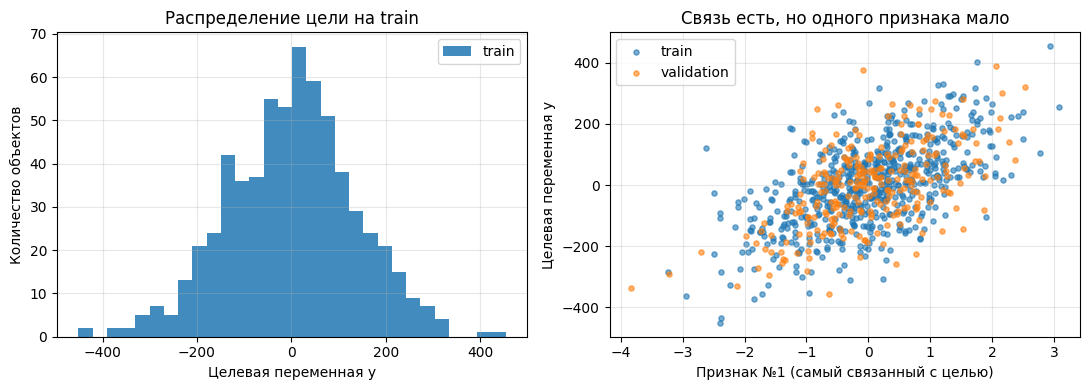

In [1]:
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X, y = make_regression(n_samples=900, n_features=10, n_informative=6,
                       noise=25, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# baseline — самая простая «модель»: всегда предсказываем среднее по train
baseline_mae = mean_absolute_error(y_val, np.full_like(y_val, y_tr.mean()))

print('train:', X_tr.shape[0], 'объектов | validation:', X_val.shape[0], 'объектов')
print('признаков:', X.shape[1], '| из них полезных: 6')
print('y меняется от', round(y.min(), 1), 'до', round(y.max(), 1))
print('baseline (всегда среднее по train): MAE =', round(baseline_mae, 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y_tr, bins=30, color='tab:blue', alpha=0.85, label='train')
axes[0].set_xlabel('Целевая переменная y')
axes[0].set_ylabel('Количество объектов')
axes[0].set_title('Распределение цели на train')
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].scatter(X_tr[:, 1], y_tr, s=14, alpha=0.6, label='train')
axes[1].scatter(X_val[:, 1], y_val, s=14, alpha=0.6, label='validation')
axes[1].set_xlabel('Признак №1 (самый связанный с целью)')
axes[1].set_ylabel('Целевая переменная y')
axes[1].set_title('Связь есть, но одного признака мало')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** В train попало 630 объектов, в validation — 270. Цель разбросана примерно от −451 до 455. Простейший baseline «всегда предсказываю среднее» ошибается в среднем на **105.5** — это планка, которую любая модель обязана перебить.

На правом графике видно, зачем вообще нужна модель: связь признака №1 с целью заметна, но точки образуют широкое облако. Одного признака мало, нужно учитывать все десять сразу — этим и займётся бустинг.

## 1. Последовательное исправление ошибок

Разберём алгоритм на четырёх точках, где всё можно посчитать в уме.

**Остаток** (residual) — это промах модели на конкретном объекте: $r_i = y_i - \hat y_i$. Положительный остаток означает «модель занизила», отрицательный — «завысила».

Алгоритм бустинга для регрессии:

1. начать с самого простого прогноза $F_0$ — константы (среднего значения цели);
2. посчитать остатки $r_i = y_i - F(x_i)$ — кто и насколько недополучил;
3. обучить маленькое дерево предсказывать **не цель, а остатки**;
4. добавить прогноз дерева к ансамблю с небольшим коэффициентом $\eta$;
5. вернуться к шагу 2.

Формула обновления: $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$, где $h_m$ — новое дерево, а $\eta$ (греческая буква «эта») — **learning rate**, темп обучения. Про него подробно в п. 4.

Дерево глубины 1 (его называют **пень**, англ. *stump*) умеет ровно одно: задать один вопрос вида «$x \le$ порог?» и выдать два числа — по одному на каждую половину.

Итоговый прогноз — это константа плюс сумма маленьких поправок от всех деревьев.

Константный прогноз F0 = 18.0
Вопрос дерева: x <= 6.5 ?
MAE было 6.0 -> стало 4.8


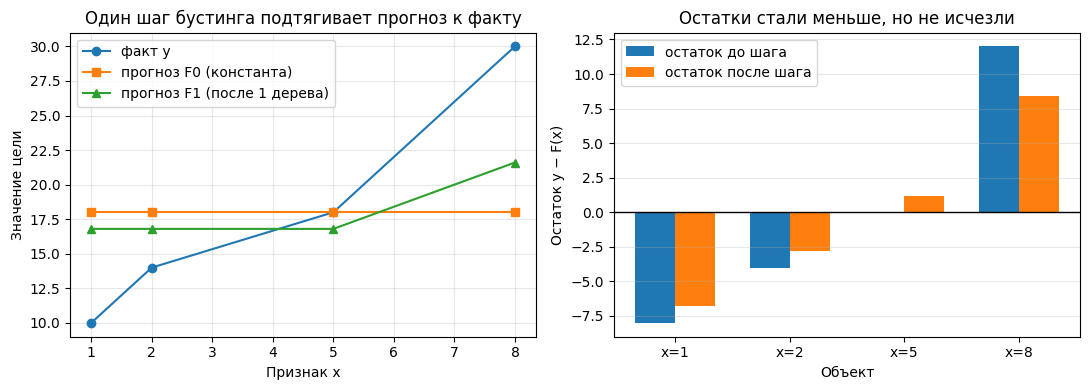

,x,y (факт),F0,остаток r,дерево h(x),F1 = F0 + 0.3·h(x)
0,1.0,10.0,18.0,-8.0,-4.0,16.8
1,2.0,14.0,18.0,-4.0,-4.0,16.8
2,5.0,18.0,18.0,0.0,-4.0,16.8
3,8.0,30.0,18.0,12.0,12.0,21.6


In [2]:
from sklearn.tree import DecisionTreeRegressor

x_step = np.array([1., 2., 5., 8.]).reshape(-1, 1)  # признак объекта
y_step = np.array([10., 14., 18., 30.])             # то, что нужно предсказать

pred0 = np.full_like(y_step, y_step.mean())   # F0: константа = среднее
residual0 = y_step - pred0                    # остатки: куда и насколько промахнулись

stump = DecisionTreeRegressor(max_depth=1).fit(x_step, residual0)  # дерево учится на ОСТАТКАХ
correction = stump.predict(x_step)

learning_rate = 0.3
pred1 = pred0 + learning_rate * correction    # F1 = F0 + eta * h(x)

print('Константный прогноз F0 =', y_step.mean())
print('Вопрос дерева: x <=', stump.tree_.threshold[0], '?')
print('MAE было', round(np.mean(np.abs(y_step - pred0)), 2),
      '-> стало', round(np.mean(np.abs(y_step - pred1)), 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_step, y_step, marker='o', label='факт y')
axes[0].plot(x_step, pred0, marker='s', label='прогноз F0 (константа)')
axes[0].plot(x_step, pred1, marker='^', label='прогноз F1 (после 1 дерева)')
axes[0].set_xlabel('Признак x')
axes[0].set_ylabel('Значение цели')
axes[0].set_title('Один шаг бустинга подтягивает прогноз к факту')
axes[0].grid(alpha=0.3)
axes[0].legend()

width = 0.35
pos = np.arange(len(y_step))
axes[1].bar(pos - width / 2, residual0, width, label='остаток до шага')
axes[1].bar(pos + width / 2, y_step - pred1, width, label='остаток после шага')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(pos, [f'x={v:g}' for v in x_step.ravel()])
axes[1].set_xlabel('Объект')
axes[1].set_ylabel('Остаток y − F(x)')
axes[1].set_title('Остатки стали меньше, но не исчезли')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'x': x_step.ravel(), 'y (факт)': y_step, 'F0': pred0,
              'остаток r': residual0, 'дерево h(x)': correction,
              'F1 = F0 + 0.3·h(x)': pred1.round(2)})

**Что видно.** Среднее четырёх значений равно 18, поэтому $F_0 = 18$ для всех объектов. Остатки получились $-8,\ -4,\ 0,\ +12$: сильнее всего модель занижает последнюю точку.

Дерево-пень выбрало вопрос «$x \le 6{,}5$?». Слева от порога три объекта с остатками $-8, -4, 0$ — их среднее равно $-4$, и дерево возвращает для них $-4$. Справа один объект с остатком $+12$ — дерево возвращает $+12$.

Мы добавляем к прогнозу не всю поправку, а её треть ($\eta = 0.3$): $18 + 0.3 \cdot (-4) = 16.8$ и $18 + 0.3 \cdot 12 = 21.6$. Средняя абсолютная ошибка упала с **6.0** до **4.8**. Остатки стали $-6.8,\ -2.8,\ +1.2,\ +8.4$ — меньше, но работа не закончена.

## 2. Несколько последовательных шагов

После первого исправления остатки считают **заново**. Второе дерево видит уже другие числа, поэтому решает и другую задачу.

Здесь важна деталь, которую легко пропустить: дерево каждый раз выбирает вопрос там, где сейчас **самая крупная ошибка**. Пока крупная ошибка остаётся в одном и том же месте, деревья будут повторять один и тот же вопрос. Как только эта ошибка станет сравнима с остальными, следующее дерево переключится на другую границу.

Сделаем четыре шага и посмотрим на пороги и остатки.

шаг 1: вопрос «x <= 6.5», остатки [-6.8 -2.8  1.2  8.4], MAE = 4.80
шаг 2: вопрос «x <= 6.5», остатки [-5.96 -1.96  2.04  5.88], MAE = 3.96
шаг 3: вопрос «x <= 3.5», остатки [-4.77 -0.77  0.85  4.69], MAE = 2.77
шаг 4: вопрос «x <= 3.5», остатки [-3.94  0.06  0.02  3.86], MAE = 1.97


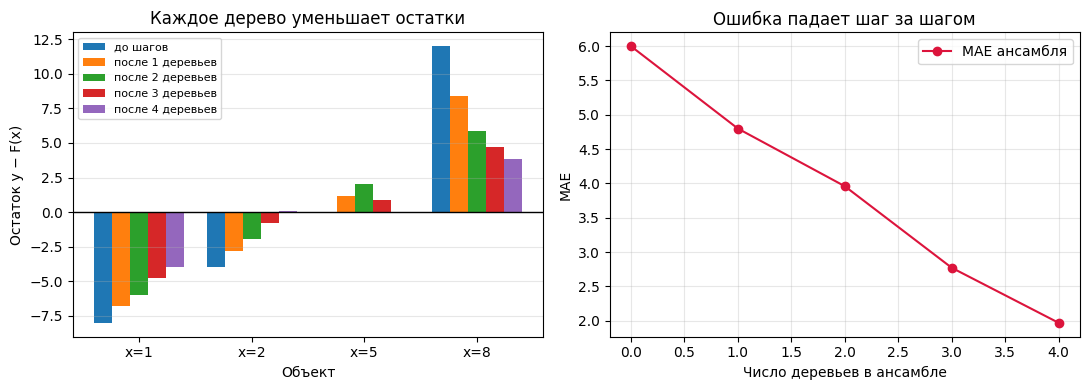

In [3]:
pred = np.full_like(y_step, y_step.mean())
residual_history = [y_step - pred]
mae_history = [float(np.mean(np.abs(y_step - pred)))]

for step in range(1, 5):
    r = y_step - pred                                     # остатки текущего ансамбля
    stump_i = DecisionTreeRegressor(max_depth=1).fit(x_step, r)
    threshold = float(stump_i.tree_.threshold[0])
    pred = pred + learning_rate * stump_i.predict(x_step)  # добавили дерево в ансамбль
    residual_history.append(y_step - pred)
    mae_history.append(float(np.mean(np.abs(y_step - pred))))
    print(f'шаг {step}: вопрос «x <= {threshold}», '
          f'остатки {np.round(y_step - pred, 2)}, MAE = {mae_history[-1]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
width = 0.16
pos = np.arange(len(y_step))
for s, r in enumerate(residual_history):
    label = 'до шагов' if s == 0 else f'после {s} деревьев'
    axes[0].bar(pos + (s - 2) * width, r, width, label=label)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xticks(pos, [f'x={v:g}' for v in x_step.ravel()])
axes[0].set_xlabel('Объект')
axes[0].set_ylabel('Остаток y − F(x)')
axes[0].set_title('Каждое дерево уменьшает остатки')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=8)

axes[1].plot(range(len(mae_history)), mae_history, marker='o', color='crimson',
             label='MAE ансамбля')
axes[1].set_xlabel('Число деревьев в ансамбле')
axes[1].set_ylabel('MAE')
axes[1].set_title('Ошибка падает шаг за шагом')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** MAE идёт вниз: **6.00 → 4.80 → 3.96 → 2.77 → 1.97**. Столбики остатков сжимаются к нулю: у объекта $x=8$ остаток падает с $+12$ до $+3.86$, у объекта $x=1$ — с $-8$ до $-3.94$.

Пороги деревьев: **6.5, 6.5, 3.5, 3.5**. Первые два дерева задают один и тот же вопрос — самая большая ошибка всё ещё у правой точки, и её выгоднее исправлять дальше. К третьему шагу правая точка подтянулась, и теперь крупнее всего промах у левой пары: дерево меняет вопрос на «$x \le 3{,}5$».

Отсюда главное свойство бустинга: **порядок деревьев важен**. Это не мешок одинаковых моделей — каждое дерево обучено на остатках, которые оставили ему предыдущие. Переставить деревья местами нельзя, а выбросить последнее — можно (это и делают, когда ограничивают их число).

## 3. Почему бустинг «градиентный» *

*Раздел со звёздочкой: полезно понимать идею, но формулы можно не заучивать.*

**Градиент** — это направление самого быстрого роста функции; **антиградиент** (градиент со знаком минус) — направление самого быстрого убывания. Бустинг на каждом шаге спрашивает: «в какую сторону сдвинуть прогноз, чтобы потеря уменьшилась быстрее всего?» — и обучает дерево приближать этот ответ.

Проверим на одном объекте. Пусть правильный ответ $y = 18$, а текущий прогноз $F = 10$. Квадратичная потеря равна $L = (y - F)^2 = 64$. Её производная по прогнозу: $\dfrac{\partial L}{\partial F} = -2 (y - F) = -16$. Значит, антиградиент равен $+16$ — прогноз надо **увеличивать**.

А остаток равен $y - F = 8$, то есть ровно половина антиградиента. Постоянный множитель 2 растворяется в `learning_rate`, поэтому **для квадратичной потери «учиться на остатках» и «идти по антиградиенту» — это одно и то же**.

Для других функций потерь (например, для классификации) формула другая, но идея та же: считаем антиградиент, обучаем дерево приближать его, делаем маленький шаг.

Потеря в текущей точке L = 64.0
Производная dL/dF = -16.0 -> антиградиент = 16.0
Остаток y - F = 8.0 = половина антиградиента


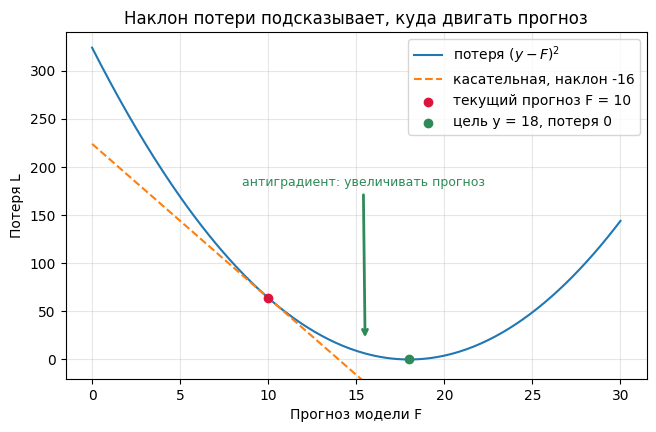

In [4]:
y_one, f_one = 18.0, 10.0                     # правильный ответ и текущий прогноз
grid = np.linspace(0, 30, 300)
loss_curve = (y_one - grid) ** 2              # потеря как функция прогноза
slope = -2 * (y_one - f_one)                  # производная потери в текущей точке
tangent = (y_one - f_one) ** 2 + slope * (grid - f_one)

print('Потеря в текущей точке L =', (y_one - f_one) ** 2)
print('Производная dL/dF =', slope, '-> антиградиент =', -slope)
print('Остаток y - F =', y_one - f_one, '= половина антиградиента')

plt.figure(figsize=(7.5, 4.5))
plt.plot(grid, loss_curve, label='потеря $(y - F)^2$')
plt.plot(grid, tangent, ls='--', color='tab:orange',
         label=f'касательная, наклон {slope:.0f}')
plt.scatter([f_one], [(y_one - f_one) ** 2], color='crimson', zorder=5,
            label=f'текущий прогноз F = {f_one:.0f}')
plt.scatter([y_one], [0], color='seagreen', zorder=5,
            label=f'цель y = {y_one:.0f}, потеря 0')
plt.annotate('антиградиент: увеличивать прогноз',
             xy=(f_one + 5.5, 20), xytext=(f_one - 1.5, 180),
             arrowprops=dict(arrowstyle='->', color='seagreen', lw=2),
             color='seagreen', fontsize=9)
plt.ylim(-20, 340)
plt.xlabel('Прогноз модели F')
plt.ylabel('Потеря L')
plt.title('Наклон потери подсказывает, куда двигать прогноз')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Что видно.** Парабола — это потеря как функция прогноза: она равна нулю в точке $F = 18$ (попали в цель) и растёт в обе стороны. В точке $F = 10$ касательная идёт вниз-вправо с наклоном $-16$: если увеличить прогноз, потеря уменьшится.

Именно это число (со знаком минус, то есть $+16$) и есть направление шага. Дерево на каждом шаге бустинга приближает такие направления сразу для всех объектов, а `learning_rate` решает, какую часть шага реально сделать.

## 4. Learning rate и число деревьев

**Learning rate** ($\eta$, параметр `learning_rate`, другое название — **shrinkage**, «сжатие шага») — множитель, с которым прогноз каждого дерева попадает в ансамбль: $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$.

Эти два параметра работают в паре:

- маленький `learning_rate` — шаг осторожный, каждое дерево меняет мало, поэтому **нужно больше деревьев**;
- большой `learning_rate` — быстрый прогресс на первых деревьях, но ансамбль легче проскакивает хорошее решение и подстраивается под шум.

Поэтому `learning_rate` и `n_estimators` (число деревьев) **подбирают совместно**: сравнивать их при фиксированном числе деревьев можно, но вывод «маленький шаг хуже» из такого сравнения делать нельзя.

Посмотрим на validation-ошибку как функцию числа деревьев для четырёх значений темпа. Метод `staged_predict` выдаёт прогнозы ансамбля после каждого добавленного дерева — это позволяет построить всю кривую, обучив модель один раз.

learning_rate=0.02: после 50 деревьев MAE 73.6; после 400 деревьев 33.4; лучшее 33.4 на 400 деревьях


learning_rate=0.05: после 50 деревьев MAE 53.2; после 400 деревьев 30.7; лучшее 30.7 на 392 деревьях


learning_rate=0.2: после 50 деревьев MAE 33.6; после 400 деревьев 31.2; лучшее 31.2 на 395 деревьях


learning_rate=0.5: после 50 деревьев MAE 40.8; после 400 деревьев 41.5; лучшее 40.3 на 38 деревьях


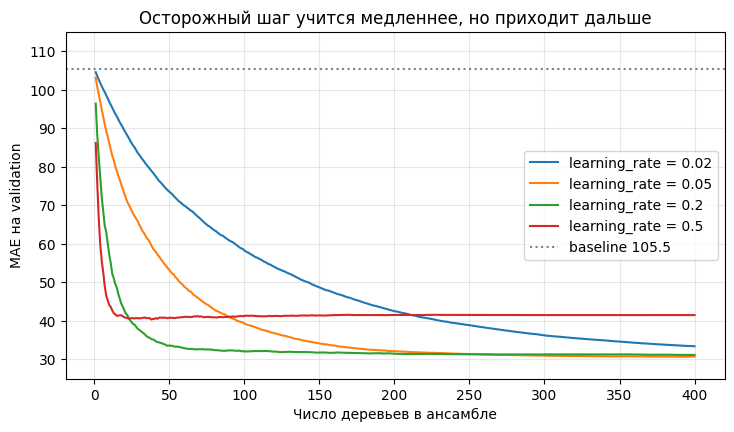

In [5]:
from sklearn.ensemble import GradientBoostingRegressor

plt.figure(figsize=(8.5, 4.5))
for lr in [0.02, 0.05, 0.2, 0.5]:
    model_lr = GradientBoostingRegressor(n_estimators=400, learning_rate=lr,
                                         max_depth=3, random_state=42).fit(X_tr, y_tr)
    curve = np.array([mean_absolute_error(y_val, p)
                      for p in model_lr.staged_predict(X_val)])
    best_i = int(np.argmin(curve))
    print(f'learning_rate={lr}: после 50 деревьев MAE {curve[49]:.1f}; '
          f'после 400 деревьев {curve[-1]:.1f}; '
          f'лучшее {curve[best_i]:.1f} на {best_i + 1} деревьях')
    plt.plot(range(1, len(curve) + 1), curve, label=f'learning_rate = {lr}')

plt.axhline(baseline_mae, color='gray', ls=':', label=f'baseline {baseline_mae:.1f}')
plt.ylim(25, 115)
plt.xlabel('Число деревьев в ансамбле')
plt.ylabel('MAE на validation')
plt.title('Осторожный шаг учится медленнее, но приходит дальше')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Что видно.** После 50 деревьев лидирует `learning_rate = 0.2` (MAE **33.6**), а самый осторожный `0.02` ещё далеко позади (**73.6**) — он просто не успел. Но к 400 деревьям картина меняется: лучший результат у `learning_rate = 0.05` — **30.7**, у `0.2` — **31.2**, а `0.02` дошёл только до **33.4** и продолжал бы улучшаться дальше.

Самый крупный шаг `0.5` — худший на всём графике: его лучшее значение **40.3** достигается уже на 38 деревьях, а дальше кривая идёт вверх. Это переобучение, к которому мы вернёмся в п. 7.

Вывод для практики: `learning_rate` вокруг 0.05–0.1 плюс «много» деревьев — разумная стартовая точка, а число деревьев выбирают по validation, а не наугад.

## 5. Слабые деревья

Базовые деревья в бустинге делают неглубокими. Глубина задаёт, насколько сложное правило умеет выразить одно дерево:

- **глубина 1** — одно условие, объекты делятся на две группы;
- **глубина 2** — два условия подряд, до четырёх групп; уже может учесть, что важна комбинация двух признаков;
- **глубина 6–8** — сотни листьев, дерево способно запомнить отдельные объекты train.

Ансамбль неглубоких деревьев всё равно выражает сложную функцию — просто складывает много простых правил. А вот ансамбль глубоких деревьев переобучается очень быстро: каждое дерево уже само по себе почти запоминает данные.

Проверим на сквозном датасете при фиксированных 200 деревьях и `learning_rate = 0.05`.

 глубина  train MAE  validation MAE
       1       38.6            45.7
       2       21.3            34.4
       3       14.4            32.1
       5        6.0            35.8
       8        0.1            47.7


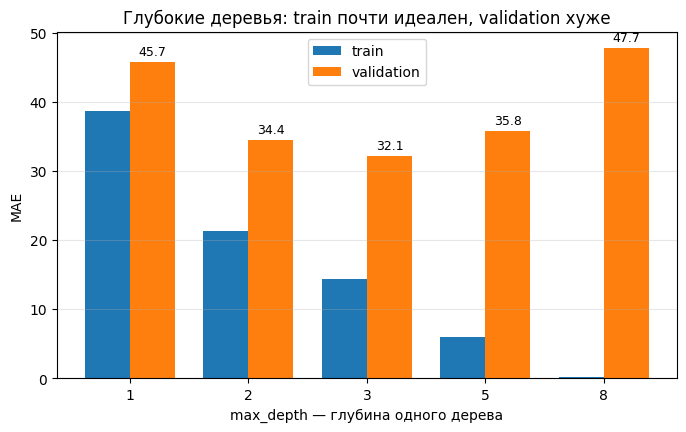

In [6]:
depth_rows = []
for depth in [1, 2, 3, 5, 8]:
    model_d = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=depth, random_state=42).fit(X_tr, y_tr)
    depth_rows.append({
        'глубина': depth,
        'train MAE': mean_absolute_error(y_tr, model_d.predict(X_tr)),
        'validation MAE': mean_absolute_error(y_val, model_d.predict(X_val)),
    })
depth_df = pd.DataFrame(depth_rows)
print(depth_df.round(1).to_string(index=False))

pos = np.arange(len(depth_df))
width = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(pos - width / 2, depth_df['train MAE'], width, label='train')
plt.bar(pos + width / 2, depth_df['validation MAE'], width, label='validation')
for i, row in depth_df.iterrows():
    plt.text(i + width / 2, row['validation MAE'] + 1,
             f"{row['validation MAE']:.1f}", ha='center', fontsize=9)
plt.xticks(pos, depth_df['глубина'])
plt.xlabel('max_depth — глубина одного дерева')
plt.ylabel('MAE')
plt.title('Глубокие деревья: train почти идеален, validation хуже')
plt.grid(alpha=0.3, axis='y')
plt.legend()
plt.show()

**Что видно.** Train-ошибка падает монотонно: **38.6 → 21.3 → 14.4 → 6.0 → 0.1**. При глубине 8 ансамбль практически выучил train наизусть.

Validation-ошибка ведёт себя иначе: **45.7 → 34.4 → 32.1 → 35.8 → 47.7**. Лучшая глубина — **3**; при глубине 8 результат (47.7) хуже, чем у самых простых пней (45.7), хотя на train разница колоссальная.

Это классическая картина переобучения: разрыв между столбиками train и validation растёт вместе с глубиной. Начинать настройку стоит с глубины 2–4.

## 6. Функции потерь

**Функция потерь** (loss) — это правило, по которому модель считает, насколько плох конкретный промах. Она определяет, какие ошибки бустинг будет исправлять в первую очередь. Метрика, по которой мы оцениваем модель, может быть совсем другой.

Для регрессии в sklearn доступны:

- `squared_error` — **квадратичная** потеря, среднее $(y - \hat y)^2$; это и есть **MSE** (mean squared error). Промах в 10 раз больше штрафуется в 100 раз сильнее, поэтому модель очень старается исправить выбросы. Корень из MSE называют **RMSE** (root mean squared error) — он удобнее, потому что измеряется в единицах цели;
- `absolute_error` — **абсолютная** потеря, среднее $|y - \hat y|$ (это MAE). Все промахи важны одинаково, выбросы не перетягивают внимание;
- `huber` — **потеря Хьюбера**: ведёт себя как квадратичная для маленьких ошибок и как абсолютная для больших. Компромисс между чувствительностью и устойчивостью.

Для классификации по умолчанию используется **log loss** (логарифмическая потеря, она же логистическая): она штрафует не за неправильный класс, а за **уверенность в неправильном ответе**.

Проверим устойчивость на эксперименте: испортим 8% обучающих ответов — как если бы в базе часть цен записали с лишним нулём. Validation оставим чистой.

Испортили 50 обучающих ответов из 630


squared_error   (квадратичная): MAE на чистой validation = 54.4


absolute_error  (абсолютная): MAE на чистой validation = 34.8


huber           (Huber): MAE на чистой validation = 40.1


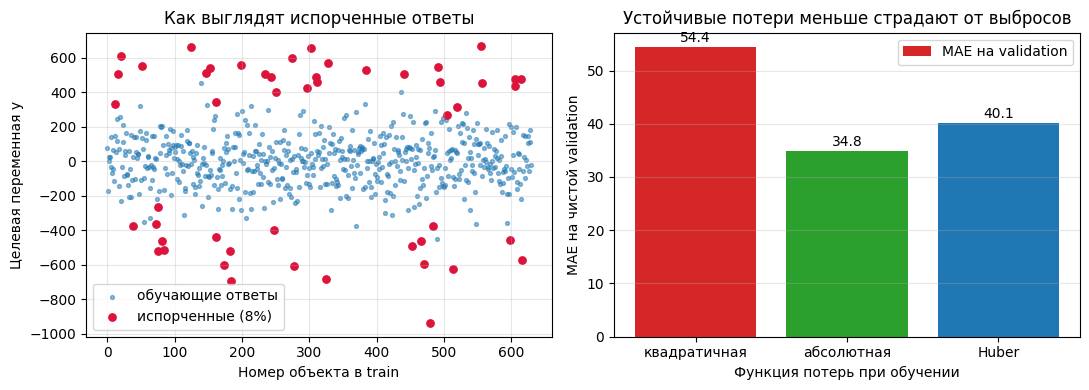

In [7]:
rng = np.random.default_rng(1)
y_tr_noisy = y_tr.copy()
broken = rng.choice(len(y_tr_noisy), int(0.08 * len(y_tr_noisy)), replace=False)
y_tr_noisy[broken] += rng.choice([-1.0, 1.0], len(broken)) * 500
print('Испортили', len(broken), 'обучающих ответов из', len(y_tr))

loss_names = [('squared_error', 'квадратичная'),
              ('absolute_error', 'абсолютная'),
              ('huber', 'Huber')]
loss_mae = []
for loss_name, rus in loss_names:
    model_loss = GradientBoostingRegressor(loss=loss_name, n_estimators=200,
                                           learning_rate=0.08, max_depth=3,
                                           random_state=42).fit(X_tr, y_tr_noisy)
    loss_mae.append(mean_absolute_error(y_val, model_loss.predict(X_val)))
    print(f'{loss_name:15s} ({rus}): MAE на чистой validation = {loss_mae[-1]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(np.arange(len(y_tr)), y_tr_noisy, s=8, alpha=0.5, label='обучающие ответы')
axes[0].scatter(broken, y_tr_noisy[broken], s=28, color='crimson',
                label='испорченные (8%)')
axes[0].set_xlabel('Номер объекта в train')
axes[0].set_ylabel('Целевая переменная y')
axes[0].set_title('Как выглядят испорченные ответы')
axes[0].grid(alpha=0.3)
axes[0].legend()

colors = ['tab:red', 'tab:green', 'tab:blue']
axes[1].bar([rus for _, rus in loss_names], loss_mae, color=colors, label='MAE на validation')
for i, v in enumerate(loss_mae):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_xlabel('Функция потерь при обучении')
axes[1].set_ylabel('MAE на чистой validation')
axes[1].set_title('Устойчивые потери меньше страдают от выбросов')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** Пятьдесят испорченных ответов (8% от 630) видны на левом графике как две полосы далеко за пределами обычного диапазона.

Результат на чистой validation: квадратичная потеря — **54.4**, потеря Хьюбера — **40.1**, абсолютная — **34.8**. Разница почти в полтора раза, а данные и число деревьев одинаковые.

Механизм простой: квадратичная потеря считает промах в 500 единиц в тысячи раз важнее промаха в 10, поэтому почти все деревья тратятся на подгонку под 50 испорченных объектов. Абсолютная потеря относится к ним как к обычным точкам.

Практический вывод: если в данных возможны грубые ошибки в целевой переменной, `loss='absolute_error'` или `loss='huber'` — не экзотика, а первое, что стоит попробовать.

## 7. Переобучение по мере добавления деревьев

Каждое новое дерево обязано уменьшить ошибку **на train** — оно ровно для этого и обучается. Поэтому train-кривая падает всегда, и по ней невозможно понять, когда пора остановиться.

Validation-ошибка ведёт себя иначе. Сначала деревья ловят настоящую закономерность, и она падает вместе с train. Потом закономерность исчерпывается, и деревья начинают подгоняться под шум конкретной обучающей выборки — на новых данных это только мешает, и validation-ошибка растёт.

Покажем это на данных с испорченными ответами из п. 6 — там шума достаточно, чтобы эффект был хорошо виден.

train MAE: 1 дерево -> 134.5 | 300 деревьев -> 29.6
validation MAE: минимум 48.1 на 68 деревьях
validation MAE на 300 деревьях: 56.0 - это хуже минимума на 16.2 %


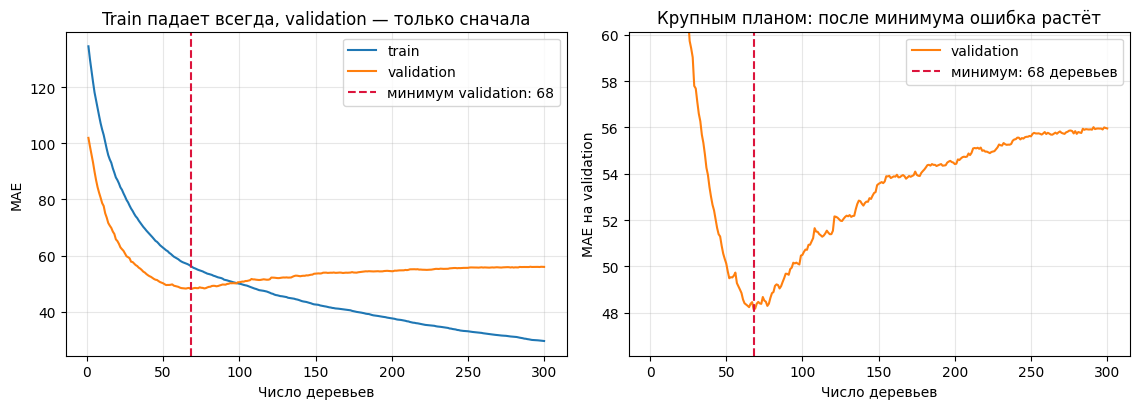

In [8]:
gb_noisy = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                     max_depth=3, random_state=42).fit(X_tr, y_tr_noisy)
train_curve = np.array([mean_absolute_error(y_tr_noisy, p)
                        for p in gb_noisy.staged_predict(X_tr)])
val_curve = np.array([mean_absolute_error(y_val, p)
                      for p in gb_noisy.staged_predict(X_val)])
n_trees = np.arange(1, len(val_curve) + 1)
best_n = int(np.argmin(val_curve)) + 1

print('train MAE: 1 дерево ->', round(train_curve[0], 1),
      '| 300 деревьев ->', round(train_curve[-1], 1))
print('validation MAE: минимум', round(val_curve.min(), 1), 'на', best_n, 'деревьях')
print('validation MAE на 300 деревьях:', round(val_curve[-1], 1),
      '- это хуже минимума на', round(100 * (val_curve[-1] / val_curve.min() - 1), 1), '%')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(n_trees, train_curve, label='train')
axes[0].plot(n_trees, val_curve, label='validation')
axes[0].axvline(best_n, color='crimson', ls='--', label=f'минимум validation: {best_n}')
axes[0].set_xlabel('Число деревьев')
axes[0].set_ylabel('MAE')
axes[0].set_title('Train падает всегда, validation — только сначала')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(n_trees, val_curve, color='tab:orange', label='validation')
axes[1].axvline(best_n, color='crimson', ls='--', label=f'минимум: {best_n} деревьев')
axes[1].set_ylim(val_curve.min() - 2, val_curve.min() + 12)
axes[1].set_xlabel('Число деревьев')
axes[1].set_ylabel('MAE на validation')
axes[1].set_title('Крупным планом: после минимума ошибка растёт')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** Train-кривая уходит вниз без остановки: с **134.5** после первого дерева до **29.6** после трёхсотого.

Validation-кривая достигает минимума **48.1** на **68** деревьях, а к 300 деревьям поднимается до **56.0** — на **16.2%** хуже. Правый график — та же кривая с растянутой вертикальной осью: подъём после минимума виден отчётливо.

Практический смысл: 232 «лишних» дерева не просто потрачены зря — они сделали модель хуже. Оптимальное число деревьев — такой же гиперпараметр, как глубина, и выбирают его по validation.

> Обратите внимание: на **чистых** данных (п. 4) кривые тоже выходили на плато, но заметно поднимался только самый крупный шаг `learning_rate = 0.5`. Чем больше шума в разметке и чем крупнее шаг, тем раньше и сильнее подъём.

**Ещё одна ручка: `subsample`.** По умолчанию каждое дерево видит весь train. Если поставить `subsample < 1`, каждое дерево будет обучаться на случайной доле объектов — это называется **стохастический градиентный бустинг**. Идея та же, что в bagging: случайность мешает деревьям дружно подстраиваться под одни и те же шумные точки. В библиотеках XGBoost и LightGBM есть и родственный параметр `colsample_bytree` — доля признаков на дерево.

Важно: это не волшебная кнопка. Проверим на наших данных.

subsample=1.0: лучшее MAE 48.1 на 68 деревьях; на 300 деревьях 56.0


subsample=0.7: лучшее MAE 48.0 на 58 деревьях; на 300 деревьях 57.7


subsample=0.5: лучшее MAE 52.3 на 56 деревьях; на 300 деревьях 63.2


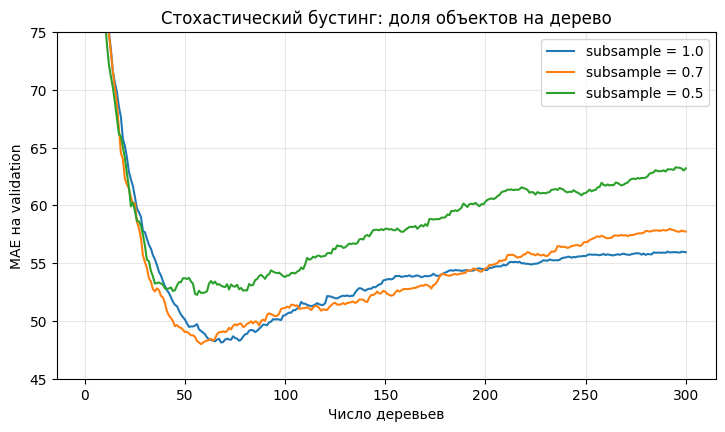

In [9]:
plt.figure(figsize=(8.5, 4.5))
for sub in [1.0, 0.7, 0.5]:
    model_sub = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                          max_depth=3, subsample=sub,
                                          random_state=42).fit(X_tr, y_tr_noisy)
    curve = np.array([mean_absolute_error(y_val, p)
                      for p in model_sub.staged_predict(X_val)])
    best_i = int(np.argmin(curve))
    print(f'subsample={sub}: лучшее MAE {curve[best_i]:.1f} на {best_i + 1} деревьях; '
          f'на 300 деревьях {curve[-1]:.1f}')
    plt.plot(range(1, len(curve) + 1), curve, label=f'subsample = {sub}')

plt.ylim(45, 75)
plt.xlabel('Число деревьев')
plt.ylabel('MAE на validation')
plt.title('Стохастический бустинг: доля объектов на дерево')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Что видно.** Лучшие точки кривых: `subsample = 1.0` — **48.1**, `subsample = 0.7` — **48.0**, `subsample = 0.5` — **52.3**. То есть умеренное прореживание не изменило ничего, а сильное (половина объектов на дерево) заметно ухудшило результат: на 630 обучающих объектах деревьям просто не хватает данных.

Это честный результат эксперимента, а не неудача. Вывод такой: `subsample` — параметр, который **проверяют на validation**, а не включают по умолчанию «для регуляризации». На больших выборках он часто помогает и всегда ускоряет обучение; на маленьких может навредить.

## 8. Автоматическая остановка обучения (early stopping)

В п. 7 мы выбрали число деревьев **post-hoc** (лат. «после этого»): обучили все 300, посмотрели на кривую и задним числом решили, что лучшая точка — 68 деревьев. Способ рабочий, но обучение полностью оплачено.

**Early stopping** («ранняя остановка») делает то же самое во время обучения. sklearn откладывает часть train во внутреннюю validation (`validation_fraction`) и прекращает добавлять деревья, если качество на ней не улучшается `n_iter_no_change` итераций подряд (улучшением считается изменение больше `tol`). Итоговое число деревьев лежит в атрибуте `n_estimators_`.

Разница между способами важна:

| | Post-hoc выбор | Early stopping |
|---|---|---|
| Когда решаем | после полного обучения | во время обучения |
| По какой выборке | по вашей внешней validation | по внутренней доле train |
| Стоимость | обучаем все `n_estimators` | останавливаемся раньше |
| Риск | нужен отдельный набор данных | внутренняя доля может быть маленькой и «шумной» |

И в том, и в другом случае финальную оценку делают **один раз** на отдельном test — данных, которые не участвовали ни в обучении, ни в выборе числа деревьев.

Без остановки : 300 деревьев, MAE 56.0, обучение 0.82 c
Early stopping: 129 деревьев, MAE 52.4, обучение 0.30 c
Post-hoc выбор: 68 деревьев, MAE 48.1


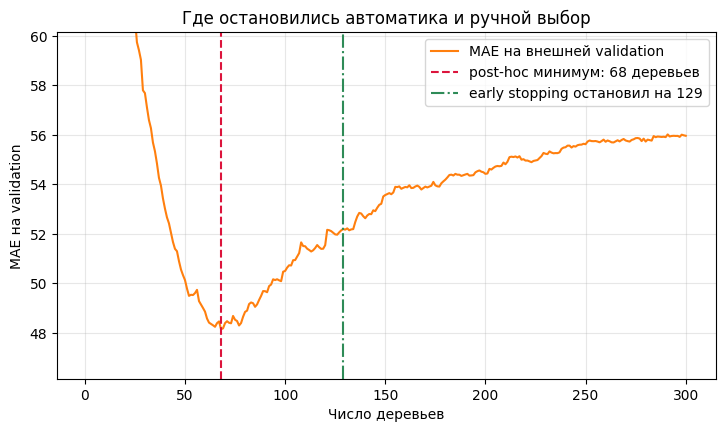

In [10]:
t0 = time.perf_counter()
full_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                       max_depth=3, random_state=42).fit(X_tr, y_tr_noisy)
time_full = time.perf_counter() - t0

t0 = time.perf_counter()
early_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08, max_depth=3,
                                        validation_fraction=0.2, n_iter_no_change=15,
                                        tol=1e-4, random_state=42).fit(X_tr, y_tr_noisy)
time_early = time.perf_counter() - t0

mae_full = mean_absolute_error(y_val, full_model.predict(X_val))
mae_early = mean_absolute_error(y_val, early_model.predict(X_val))

print(f'Без остановки : 300 деревьев, MAE {mae_full:.1f}, обучение {time_full:.2f} c')
print(f'Early stopping: {early_model.n_estimators_} деревьев, '
      f'MAE {mae_early:.1f}, обучение {time_early:.2f} c')
print(f'Post-hoc выбор: {best_n} деревьев, MAE {val_curve[best_n - 1]:.1f}')

plt.figure(figsize=(8.5, 4.5))
plt.plot(n_trees, val_curve, color='tab:orange', label='MAE на внешней validation')
plt.axvline(best_n, color='crimson', ls='--',
            label=f'post-hoc минимум: {best_n} деревьев')
plt.axvline(early_model.n_estimators_, color='seagreen', ls='-.',
            label=f'early stopping остановил на {early_model.n_estimators_}')
plt.ylim(val_curve.min() - 2, val_curve.min() + 12)
plt.xlabel('Число деревьев')
plt.ylabel('MAE на validation')
plt.title('Где остановились автоматика и ручной выбор')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Что видно.** Все 300 деревьев дают MAE **56.0**. Early stopping остановился на **129** деревьях и дал **52.4** — лучше, чем полное обучение, и дешевле: деревьев построено в 2.3 раза меньше, ровно во столько же раз короче обучение. Post-hoc выбор по внешней validation нашёл ещё лучшую точку: **68** деревьев и MAE **48.1**.

Почему автоматика остановилась позже оптимума? Она смотрит не на нашу validation, а на свои 20% от train — а эти 20% содержат те же испорченные ответы, что и остальной train. По такой выборке подъём ошибки заметен позже.

Вывод без прикрас: early stopping — дешёвая страховка от «слишком долго учили», но он **не заменяет** честную внешнюю проверку. Если данных хватает, лучше иметь и внешнюю validation, и early stopping.

## 9. Когда внутренняя validation неверна

И early stopping, и post-hoc выбор опираются на одно предположение: **отложенные объекты действительно новые для модели**. Если это не так, обе процедуры покажут завышенное качество и остановятся не там.

Типичный случай — **группы связанных объектов**: несколько замеров одного пациента, несколько фотографий одного товара, несколько заказов одного пользователя. При случайном разбиении часть объектов группы попадает в train, а часть — в validation. Модель уже видела почти такие же строки, поэтому «угадывает» их слишком хорошо.

Второй типичный случай — **временные ряды**: случайный split позволяет учиться на будущем и предсказывать прошлое, чего в реальной эксплуатации никогда не будет.

Смоделируем группы: 120 групп по 5 почти одинаковых объектов и сравним два способа разбиения.

Случайный split : MAE 2.01
Split по группам: MAE 5.41
Случайный split завышает качество в 2.7 раза


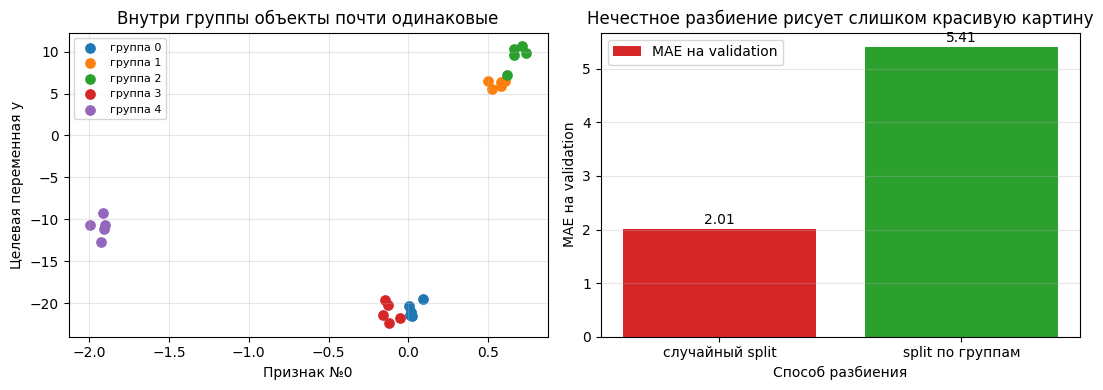

In [11]:
from sklearn.model_selection import GroupShuffleSplit

rng = np.random.default_rng(11)
n_groups, per_group = 120, 5
base = rng.normal(size=(n_groups, 6))
weights = rng.normal(size=6)

X_grp = (np.repeat(base, per_group, axis=0)
         + rng.normal(0, 0.05, size=(n_groups * per_group, 6)))     # почти дубликаты
y_grp = (np.repeat(base @ weights, per_group) * 10
         + rng.normal(0, 1.0, n_groups * per_group))
groups = np.repeat(np.arange(n_groups), per_group)

# способ 1: случайный split — объекты одной группы попадают и в train, и в validation
Xg_tr, Xg_val, yg_tr, yg_val = train_test_split(X_grp, y_grp, test_size=0.3, random_state=0)
model_random = GradientBoostingRegressor(n_estimators=150, random_state=42).fit(Xg_tr, yg_tr)
mae_random = mean_absolute_error(yg_val, model_random.predict(Xg_val))

# способ 2: split по группам — группа целиком либо в train, либо в validation
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
idx_tr, idx_val = next(splitter.split(X_grp, y_grp, groups))
model_group = GradientBoostingRegressor(n_estimators=150, random_state=42).fit(
    X_grp[idx_tr], y_grp[idx_tr])
mae_group = mean_absolute_error(y_grp[idx_val], model_group.predict(X_grp[idx_val]))

print('Случайный split : MAE', round(mae_random, 2))
print('Split по группам: MAE', round(mae_group, 2))
print('Случайный split завышает качество в', round(mae_group / mae_random, 1), 'раза')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for g in range(5):
    mask = groups == g
    axes[0].scatter(X_grp[mask, 0], y_grp[mask], s=45, label=f'группа {g}')
axes[0].set_xlabel('Признак №0')
axes[0].set_ylabel('Целевая переменная y')
axes[0].set_title('Внутри группы объекты почти одинаковые')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].bar(['случайный split', 'split по группам'], [mae_random, mae_group],
            color=['tab:red', 'tab:green'], label='MAE на validation')
for i, v in enumerate([mae_random, mae_group]):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)
axes[1].set_xlabel('Способ разбиения')
axes[1].set_ylabel('MAE на validation')
axes[1].set_title('Нечестное разбиение рисует слишком красивую картину')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** На левом графике пять групп: точки одной группы лежат почти в одной позиции — это и есть «почти дубликаты».

Случайный split даёт MAE **2.01**, а честный split по группам — **5.41**, то есть в **2.7 раза** хуже. Модель не стала хуже; просто первая цифра была неправдой: модель отвечала на вопросы, ответы на которые уже видела.

В sklearn для таких случаев есть `GroupKFold` и `GroupShuffleSplit` (разбиение по группам) и `TimeSeriesSplit` (разбиение по времени). То же правило действует и для `validation_fraction` в early stopping: внутренняя доля отрезается случайно, поэтому на группах или временных рядах на неё полагаться нельзя.

## 10. Классификация

Для классификации бустинг устроен так же, только складывает не прогнозы цели, а **внутренние числа** — их называют логитами или, в sklearn, значением `decision_function`. Это число может быть любым: от больших отрицательных (уверенно класс 0) до больших положительных (уверенно класс 1).

Схема шага:

1. ансамбль выдаёт число $F(x)$;
2. число превращается в вероятность сигмоидой: $p = \dfrac{1}{1 + e^{-F(x)}}$;
3. считается **log loss** — насколько уверенно и насколько неправильно;
4. новое дерево обучается на антиградиенте log loss. Для этой потери антиградиент равен $y - p$ — «сколько не хватило до правильного ответа в вероятностях»;
5. класс получается из вероятности по **порогу** (по умолчанию 0.5).

Как и в логистической регрессии (занятие 31), порог — отдельное решение: его выбирают исходя из цены ошибок **FP** (false positive, ложная тревога) и **FN** (false negative, пропуск).

Возьмём задачу классификации на 1200 объектов, где 5% меток случайно перепутаны (`flip_y=0.05`) — так бывает при неаккуратной разметке.

train log loss: 0.653 -> 0.073
validation log loss: минимум 0.323 на 110 деревьях; на 200 деревьях 0.329
accuracy 0.881 | ROC-AUC 0.934
decision_function на validation: от -6.4 до 6.4


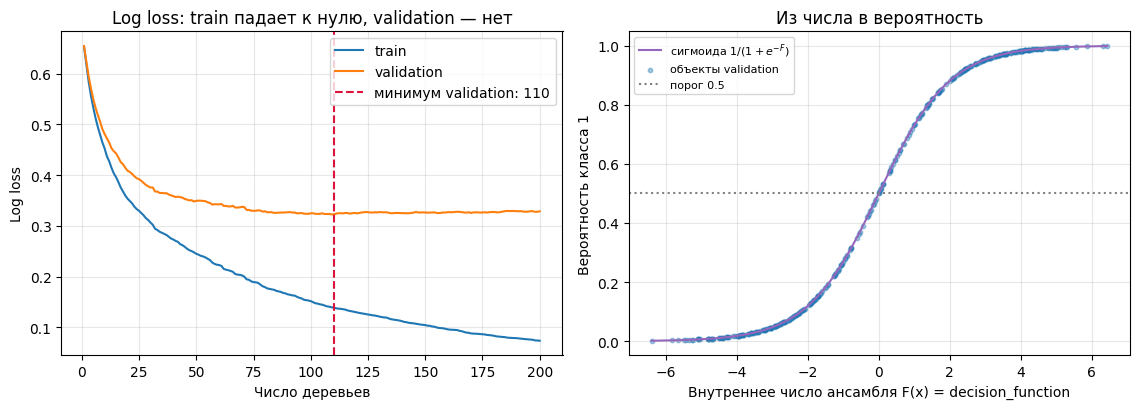

In [12]:
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

X_cls, y_cls = make_classification(n_samples=1200, n_features=15, n_informative=6,
                                   flip_y=0.05, random_state=42)
Xc_tr, Xc_val, yc_tr, yc_val = train_test_split(X_cls, y_cls, test_size=0.3,
                                                random_state=42, stratify=y_cls)

clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=42).fit(Xc_tr, yc_tr)

train_ll = np.array([log_loss(yc_tr, p) for p in clf.staged_predict_proba(Xc_tr)])
val_ll = np.array([log_loss(yc_val, p) for p in clf.staged_predict_proba(Xc_val)])
best_ll = int(np.argmin(val_ll)) + 1

score_val = clf.decision_function(Xc_val)     # внутреннее число ансамбля
proba_val = clf.predict_proba(Xc_val)[:, 1]   # вероятность класса 1

print('train log loss:', round(train_ll[0], 3), '->', round(train_ll[-1], 3))
print('validation log loss: минимум', round(val_ll.min(), 3), 'на', best_ll, 'деревьях;',
      'на 200 деревьях', round(val_ll[-1], 3))
print('accuracy', round(accuracy_score(yc_val, clf.predict(Xc_val)), 3),
      '| ROC-AUC', round(roc_auc_score(yc_val, proba_val), 3))
print('decision_function на validation: от', round(score_val.min(), 1),
      'до', round(score_val.max(), 1))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
trees_axis = np.arange(1, len(val_ll) + 1)
axes[0].plot(trees_axis, train_ll, label='train')
axes[0].plot(trees_axis, val_ll, label='validation')
axes[0].axvline(best_ll, color='crimson', ls='--', label=f'минимум validation: {best_ll}')
axes[0].set_xlabel('Число деревьев')
axes[0].set_ylabel('Log loss')
axes[0].set_title('Log loss: train падает к нулю, validation — нет')
axes[0].grid(alpha=0.3)
axes[0].legend()

order = np.argsort(score_val)
axes[1].plot(score_val[order], 1 / (1 + np.exp(-score_val[order])),
             color='tab:purple', label='сигмоида $1/(1+e^{-F})$')
axes[1].scatter(score_val, proba_val, s=10, alpha=0.4, color='tab:blue',
                label='объекты validation')
axes[1].axhline(0.5, color='gray', ls=':', label='порог 0.5')
axes[1].set_xlabel('Внутреннее число ансамбля F(x) = decision_function')
axes[1].set_ylabel('Вероятность класса 1')
axes[1].set_title('Из числа в вероятность')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Что видно.** Log loss на train падает с **0.653** (первое дерево — почти незнание) до **0.073**: ансамбль отвечает на обучающих объектах уверенно и почти всегда правильно. На validation минимум **0.323** достигается на **110** деревьях, а дальше кривая идёт вбок и вверх — те же грабли, что в п. 7.

Итоговое качество: accuracy **0.881**, ROC-AUC **0.934**.

Правый график показывает третий пункт схемы вживую. Внутренние числа лежат в диапазоне примерно от **−6.4** до **+6.4**, и все точки ложатся точно на сигмоиду: $F = 0$ даёт вероятность 0.5, $F = +3$ — уже около 0.95. Именно поэтому изменить порог классификации — это то же самое, что сдвинуть вертикальную границу по оси $F$.

## 11. Вероятности классификационного бустинга

Число из `decision_function` всегда можно прогнать через сигмоиду и получить что-то в диапазоне от 0 до 1. Но «число от 0 до 1» ещё не значит «честная вероятность».

**Калибровка** — свойство вероятностей быть правдой в среднем: если модель сто раз сказала «0.8», примерно в 80 случаях должен оказаться класс 1. Бустинг с log loss обычно **переуверен**: он старается максимально развести классы, поэтому его вероятности прижимаются к 0 и 1.

Проверить это можно **калибровочной кривой** (`calibration_curve`): объекты сортируют по предсказанной вероятности, делят на корзины и в каждой сравнивают среднее предсказание с реальной долей класса 1. Идеальная калибровка — диагональ.

модель обещает 0.01 -> на самом деле класс 1 у 0.02 объектов корзины
модель обещает 0.04 -> на самом деле класс 1 у 0.07 объектов корзины
модель обещает 0.10 -> на самом деле класс 1 у 0.07 объектов корзины
модель обещает 0.29 -> на самом деле класс 1 у 0.29 объектов корзины
модель обещает 0.67 -> на самом деле класс 1 у 0.71 объектов корзины
модель обещает 0.90 -> на самом деле класс 1 у 0.91 объектов корзины
модель обещает 0.97 -> на самом деле класс 1 у 0.91 объектов корзины
модель обещает 0.99 -> на самом деле класс 1 у 0.96 объектов корзины
доля очень уверенных прогнозов (p < 0.1 или p > 0.9): 0.65


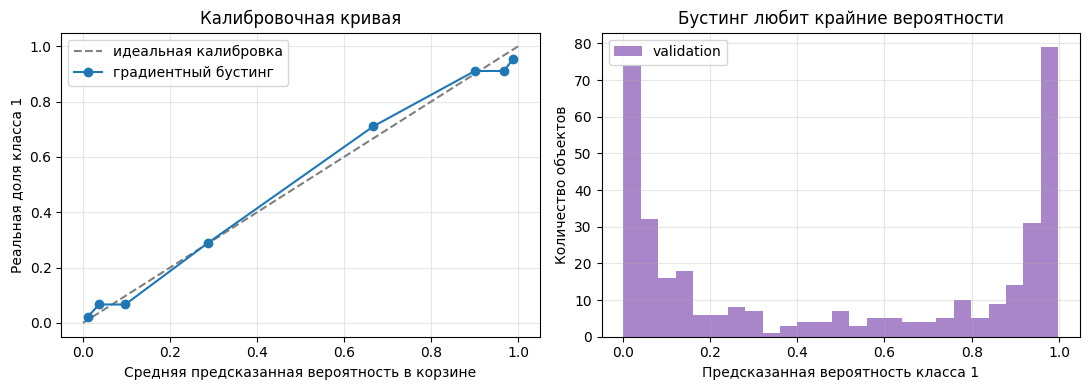

In [13]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(yc_val, proba_val, n_bins=8, strategy='quantile')
for mp, fp in zip(mean_pred, frac_pos):
    print(f'модель обещает {mp:.2f} -> на самом деле класс 1 у {fp:.2f} объектов корзины')
extreme = float(np.mean((proba_val < 0.1) | (proba_val > 0.9)))
print('доля очень уверенных прогнозов (p < 0.1 или p > 0.9):', round(extreme, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], ls='--', color='gray', label='идеальная калибровка')
axes[0].plot(mean_pred, frac_pos, marker='o', color='tab:blue',
             label='градиентный бустинг')
axes[0].set_xlabel('Средняя предсказанная вероятность в корзине')
axes[0].set_ylabel('Реальная доля класса 1')
axes[0].set_title('Калибровочная кривая')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(proba_val, bins=25, color='tab:purple', alpha=0.8, label='validation')
axes[1].set_xlabel('Предсказанная вероятность класса 1')
axes[1].set_ylabel('Количество объектов')
axes[1].set_title('Бустинг любит крайние вероятности')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** В середине шкалы калибровка приличная: обещал 0.29 — получил 0.29, обещал 0.67 — получил 0.71. А на краях модель переуверена: в корзине с обещанием **0.97** класс 1 встретился лишь у **0.91** объектов, в корзине с **0.99** — у **0.96**.

Гистограмма объясняет, откуда это берётся: **65%** всех прогнозов лежат ниже 0.1 или выше 0.9. Бустинг очень не любит говорить «не знаю».

Что с этим делать:

- если нужен только **класс**, калибровка не важна — важен порог, подобранный по validation;
- если вероятность идёт в формулу (ожидаемая прибыль, риск, приоритет заявки) — калибруйте: в sklearn для этого есть `CalibratedClassifierCV` с методами `sigmoid` (Платт) и `isotonic`;
- калибровку, как и порог, настраивают на **отдельных** данных, не на train.

## 12. Bagging и boosting

| | Random forest (bagging) | Gradient boosting |
|---|---|---|
| Обучение деревьев | независимо, каждое на своей bootstrap-выборке | последовательно, каждое на остатках предыдущих |
| Какие деревья | глубокие, сильные по отдельности | неглубокие, слабые по отдельности |
| Главная идея | усреднить много разных мнений и уменьшить разброс | шаг за шагом уменьшать ошибку |
| Что даёт добавление деревьев | ошибка выходит на плато и почти не меняется | ошибка падает дальше, но может начать расти |
| Параллельность | высокая: деревья независимы (`n_jobs=-1`) | ограниченная: дерево $m$ считается строго после $m-1$ |
| Чувствительность к настройке | небольшая, работает «из коробки» | высокая: `learning_rate`, глубина, число деревьев |

Разницу в последней строке таблицы легко увидеть: построим для обеих моделей зависимость ошибки от числа деревьев. Для леса «ансамбль из $k$ деревьев» — это среднее прогнозов первых $k$ деревьев, для бустинга — `staged_predict`.

Random forest: 10 деревьев MAE 45.8 | 300 деревьев MAE 43.4
Gradient boosting: 10 деревьев MAE 86.2 | 300 деревьев MAE 31.0


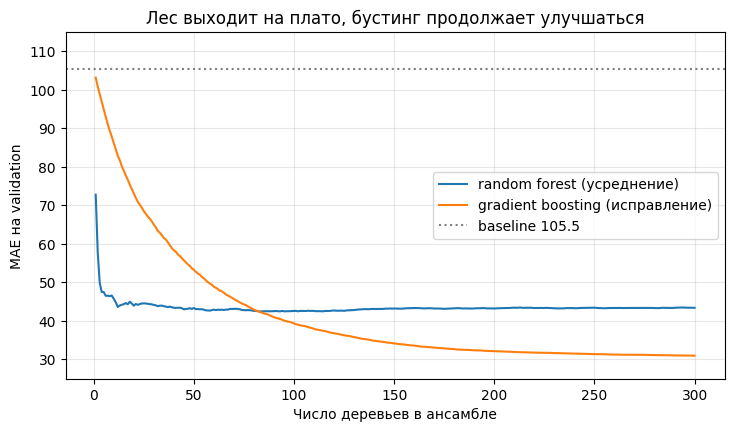

In [14]:
from sklearn.ensemble import RandomForestRegressor

t0 = time.perf_counter()
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
time_rf = time.perf_counter() - t0

t0 = time.perf_counter()
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                               random_state=42).fit(X_tr, y_tr)
time_gb = time.perf_counter() - t0

tree_preds = np.array([tree.predict(X_val) for tree in rf.estimators_])
rf_curve = np.array([mean_absolute_error(y_val, tree_preds[:k].mean(axis=0))
                     for k in range(1, len(tree_preds) + 1)])
gb_curve = np.array([mean_absolute_error(y_val, p) for p in gb.staged_predict(X_val)])

print('Random forest: 10 деревьев MAE', round(rf_curve[9], 1),
      '| 300 деревьев MAE', round(rf_curve[-1], 1))
print('Gradient boosting: 10 деревьев MAE', round(gb_curve[9], 1),
      '| 300 деревьев MAE', round(gb_curve[-1], 1))

plt.figure(figsize=(8.5, 4.5))
plt.plot(range(1, len(rf_curve) + 1), rf_curve, label='random forest (усреднение)')
plt.plot(range(1, len(gb_curve) + 1), gb_curve, label='gradient boosting (исправление)')
plt.axhline(baseline_mae, color='gray', ls=':', label=f'baseline {baseline_mae:.1f}')
plt.ylim(25, 115)
plt.xlabel('Число деревьев в ансамбле')
plt.ylabel('MAE на validation')
plt.title('Лес выходит на плато, бустинг продолжает улучшаться')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Что видно.** Лес почти сразу оказывается в своей рабочей зоне: усреднение десяти деревьев уже даёт MAE **45.8**, а все 300 улучшают результат лишь до **43.4**. Дальше добавлять деревья почти бесполезно, но и не вредно — кривая идёт горизонтально.

Бустинг стартует гораздо хуже: после десяти деревьев его MAE — **86.2**, потому что с шагом `learning_rate = 0.05` десять маленьких поправок почти не отходят от константы. Зато он не останавливается на уровне леса, а проходит его насквозь и заканчивает на **31.0**. Плата за это — риск подняться обратно на шумных данных (п. 7).

## 13. Когда лес, а когда бустинг

Ни один из двух методов не выигрывает всегда. Сравнивать их нужно **одним и тем же протоколом**: один split (или одна схема cross-validation, CV — перекрёстной проверки), одна метрика, одинаковая предобработка.

Кроме качества у моделей есть цена: время обучения, время прогноза и удобство настройки. Посмотрим на обе стороны для моделей, которые мы только что обучили.

Random forest    : MAE 43.4, обучение 0.51 c (в 300 деревьев, n_jobs=-1)
Gradient boosting: MAE 31.0, обучение 0.63 c (в 300 деревьев)
Бустинг лучше по MAE на 12.4 единицы


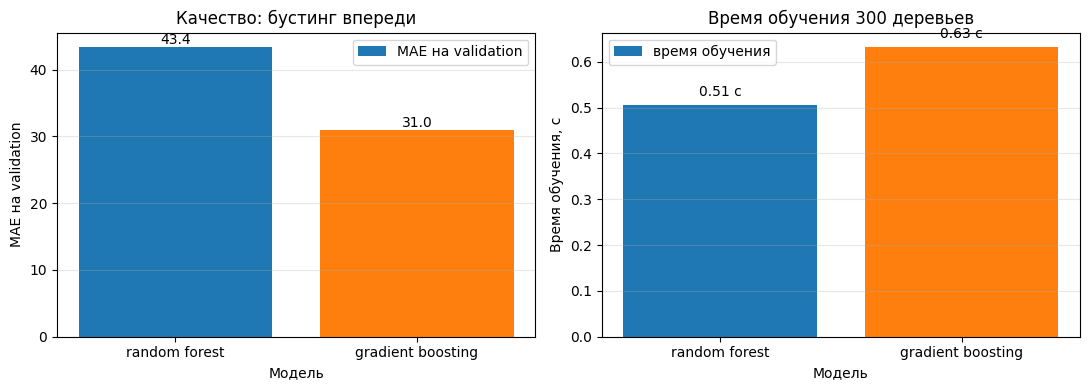

In [15]:
mae_rf = mean_absolute_error(y_val, rf.predict(X_val))
mae_gb = mean_absolute_error(y_val, gb.predict(X_val))

print(f'Random forest    : MAE {mae_rf:.1f}, обучение {time_rf:.2f} c (в 300 деревьев, n_jobs=-1)')
print(f'Gradient boosting: MAE {mae_gb:.1f}, обучение {time_gb:.2f} c (в 300 деревьев)')
print('Бустинг лучше по MAE на', round(mae_rf - mae_gb, 1), 'единицы')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ['random forest', 'gradient boosting']
axes[0].bar(names, [mae_rf, mae_gb], color=['tab:blue', 'tab:orange'],
            label='MAE на validation')
for i, v in enumerate([mae_rf, mae_gb]):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('MAE на validation')
axes[0].set_title('Качество: бустинг впереди')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend()

axes[1].bar(names, [time_rf, time_gb], color=['tab:blue', 'tab:orange'],
            label='время обучения')
for i, v in enumerate([time_rf, time_gb]):
    axes[1].text(i, v + 0.02, f'{v:.2f} c', ha='center', fontsize=10)
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('Время обучения, с')
axes[1].set_title('Время обучения 300 деревьев')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** На этих данных бустинг заметно точнее: MAE **31.0** против **43.4** у леса — выигрыш **12.4** единицы.

По времени на такой маленькой выборке модели идут вровень — доли секунды у обеих (точные секунды зависят от компьютера, смотрите на правый график). Но масштабируются они по-разному: лесу можно раздать деревья по ядрам процессора (`n_jobs=-1`), и с ростом данных он выигрывает время; бустинг обязан строить деревья строго по очереди, и ускорить его можно только внутри одного дерева (см. `HistGradientBoosting` в п. 15).

Как выбирать на практике:

- **лес** — когда нужен быстрый и надёжный baseline, мало времени на настройку, важна устойчивость к «кривым» гиперпараметрам;
- **бустинг** — когда нужно выжать максимум качества на табличных данных и есть время подобрать `learning_rate`, глубину и число деревьев;
- всегда сравнивайте оба варианта на одном протоколе и учитывайте время обучения и прогноза, а не только метрику.

## 14. Нужна ли предобработка для бустинга

Дерево не считает расстояний и не складывает признаки — оно только сравнивает признак с порогом. Поэтому:

- **масштабирование не нужно**. Умножьте признак на 1000 — пороги умножатся на 1000, а разбиения останутся теми же. Это отличает бустинг от kNN и линейных моделей с регуляризацией;
- **монотонные преобразования** (логарифм положительного признака и т. п.) тоже почти ничего не меняют для самого дерева, хотя могут помочь при интерпретации;
- **пропуски** — вот здесь разница между реализациями принципиальная. Классический `GradientBoostingRegressor` их не принимает и падает с ошибкой. `HistGradientBoostingRegressor` умеет работать с ними сам: при каждом разбиении он проверяет, в какую сторону выгоднее отправить объекты с `NaN`, и запоминает это решение;
- **категориальные признаки** нужно превратить в числа: one-hot кодирование, ordinal encoding или встроенная поддержка (`categorical_features` у `HistGradientBoosting*`, отдельный механизм у CatBoost).

Проверим первые два утверждения экспериментом.

без масштабирования: MAE 32.13
со StandardScaler  : MAE 32.13
доля пропусков в train: 0.11
GradientBoostingRegressor с пропусками -> Input X contains NaN.


HistGradientBoosting без пропусков: MAE 31.7
HistGradientBoosting с пропусками : MAE 48.0


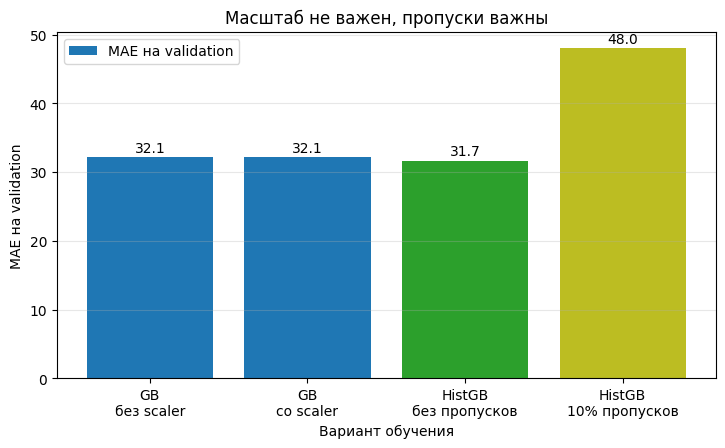

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor

scaler = StandardScaler().fit(X_tr)
model_plain = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, random_state=42).fit(X_tr, y_tr)
model_scaled = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                         max_depth=3, random_state=42).fit(
    scaler.transform(X_tr), y_tr)
mae_plain = mean_absolute_error(y_val, model_plain.predict(X_val))
mae_scaled = mean_absolute_error(y_val, model_scaled.predict(scaler.transform(X_val)))
print('без масштабирования: MAE', round(mae_plain, 3))
print('со StandardScaler  : MAE', round(mae_scaled, 3))

rng = np.random.default_rng(5)
X_tr_nan, X_val_nan = X_tr.copy(), X_val.copy()
X_tr_nan[rng.random(X_tr.shape) < 0.1] = np.nan
X_val_nan[rng.random(X_val.shape) < 0.1] = np.nan
print('доля пропусков в train:', round(float(np.isnan(X_tr_nan).mean()), 2))

try:
    GradientBoostingRegressor(n_estimators=10, random_state=42).fit(X_tr_nan, y_tr)
except ValueError as exc:
    print('GradientBoostingRegressor с пропусками ->', str(exc).splitlines()[0])

hgb_clean = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(X_tr, y_tr)
hgb_nan = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(X_tr_nan, y_tr)
mae_hgb_clean = mean_absolute_error(y_val, hgb_clean.predict(X_val))
mae_hgb_nan = mean_absolute_error(y_val, hgb_nan.predict(X_val_nan))
print('HistGradientBoosting без пропусков: MAE', round(mae_hgb_clean, 1))
print('HistGradientBoosting с пропусками : MAE', round(mae_hgb_nan, 1))

labels = ['GB\nбез scaler', 'GB\nсо scaler', 'HistGB\nбез пропусков', 'HistGB\n10% пропусков']
values = [mae_plain, mae_scaled, mae_hgb_clean, mae_hgb_nan]
plt.figure(figsize=(8.5, 4.5))
plt.bar(labels, values, color=['tab:blue', 'tab:blue', 'tab:green', 'tab:olive'],
        label='MAE на validation')
for i, v in enumerate(values):
    plt.text(i, v + 0.7, f'{v:.1f}', ha='center', fontsize=10)
plt.xlabel('Вариант обучения')
plt.ylabel('MAE на validation')
plt.title('Масштаб не важен, пропуски важны')
plt.grid(alpha=0.3, axis='y')
plt.legend()
plt.show()

**Что видно.** Первые два столбика совпадают: **32.13** без масштабирования и **32.13** со `StandardScaler`. Не «примерно одинаково», а буквально то же самое — потому что порядок объектов вдоль каждого признака не изменился, а больше дереву ничего не нужно.

Дальше про пропуски. `GradientBoostingRegressor` на данных с `NaN` останавливается с ошибкой `Input X contains NaN`. `HistGradientBoostingRegressor` обучается без единой строчки предобработки: на чистых данных он даёт MAE **31.7**, а когда 10% значений заменены на `NaN` — **48.0**.

Качество, конечно, упало: пропуски — это реальная потеря информации, и никакая модель её не вернёт. Но модель работает, и это лучше, чем падение или бездумное заполнение средним.

## 15. Обзор реализаций Gradient Boosting *

Идея бустинга одна, а реализаций много. Общее семейное название — **GBM** (gradient boosting machine).

**`HistGradientBoosting*` в sklearn** — быстрая встроенная реализация. Главный приём — **гистограммное разбиение (биннинг)**: перед обучением каждый числовой признак раскладывают максимум по 255 корзинам-«бинам». Дальше дерево ищет порог не среди всех уникальных значений (а их могут быть тысячи), а среди 255 границ корзин. Отсюда и скорость, и экономия памяти. Особенности:

- число итераций задаётся параметром `max_iter`, а не `n_estimators`;
- early stopping встроен: `early_stopping='auto'` включается сам на выборках больше 10 000 объектов;
- пропуски поддерживаются нативно, категориальные признаки — через `categorical_features`.

**XGBoost** — библиотека, с которой началась массовая мода на бустинг; много регуляризаций, работа с разреженными данными, `colsample_bytree` для случайного отбора признаков.

**LightGBM** — тоже гистограммный, но растит деревья **leaf-wise** («по листьям»): на каждом шаге делит тот лист, который даёт наибольший выигрыш, вместо того чтобы достраивать все уровни (**level-wise**). Деревья получаются несимметричными и часто точнее при том же числе разбиений, но легче переобучаются, поэтому глубину там ограничивают через `num_leaves`.

**CatBoost** — сильная сторона в категориальных признаках: вместо ручного кодирования используются **упорядоченные целевые статистики** (ordered target statistics) — категория заменяется средним значением цели, но подсчитанным только по «прошлым» объектам, чтобы не подсмотреть ответ текущего.

Названия параметров различаются, и переносить настройки между библиотеками нельзя:

| Смысл | sklearn GB | sklearn HistGB | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|---|
| Темп обучения | `learning_rate` | `learning_rate` | `eta` | `learning_rate` | `learning_rate` |
| Число деревьев | `n_estimators` | `max_iter` | `n_estimators` | `n_estimators` | `iterations` |
| Сложность дерева | `max_depth` | `max_leaf_nodes` | `max_depth` | `num_leaves` | `depth` |
| Доля объектов | `subsample` | — | `subsample` | `bagging_fraction` | `subsample` |
| Доля признаков | `max_features` | — | `colsample_bytree` | `feature_fraction` | `rsm` |

Сравним скорость двух реализаций из sklearn на выборке побольше: 12 000 объектов и 20 признаков.

GradientBoosting    : 7.1 c, MAE 32.4
HistGradientBoosting: 0.7 c, MAE 27.1
ускорение примерно в 10.4 раз


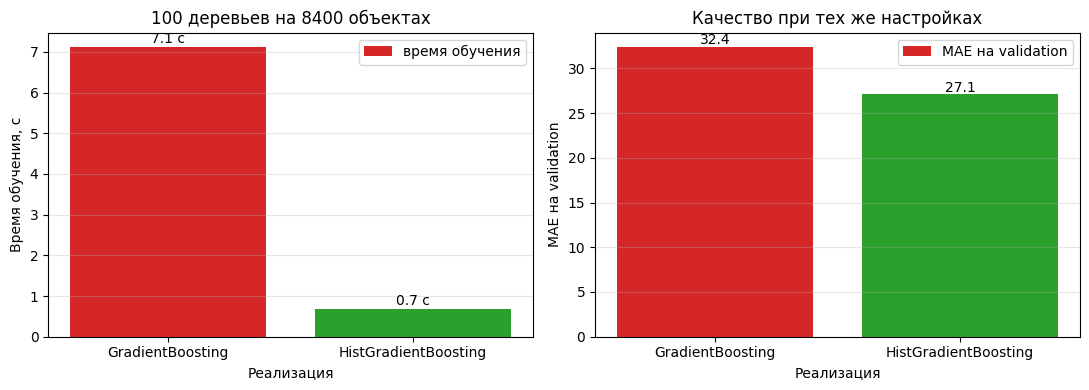

In [17]:
X_big, y_big = make_regression(n_samples=12000, n_features=20, n_informative=10,
                               noise=25, random_state=0)
Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(X_big, y_big, test_size=0.3, random_state=0)

t0 = time.perf_counter()
gb_big = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                   random_state=0).fit(Xb_tr, yb_tr)
time_gb_big = time.perf_counter() - t0

t0 = time.perf_counter()
hgb_big = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1,
                                        early_stopping=False, random_state=0).fit(Xb_tr, yb_tr)
time_hgb_big = time.perf_counter() - t0

mae_gb_big = mean_absolute_error(yb_val, gb_big.predict(Xb_val))
mae_hgb_big = mean_absolute_error(yb_val, hgb_big.predict(Xb_val))
print(f'GradientBoosting    : {time_gb_big:.1f} c, MAE {mae_gb_big:.1f}')
print(f'HistGradientBoosting: {time_hgb_big:.1f} c, MAE {mae_hgb_big:.1f}')
print('ускорение примерно в', round(time_gb_big / time_hgb_big, 1), 'раз')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ['GradientBoosting', 'HistGradientBoosting']
axes[0].bar(names, [time_gb_big, time_hgb_big], color=['tab:red', 'tab:green'],
            label='время обучения')
for i, v in enumerate([time_gb_big, time_hgb_big]):
    axes[0].text(i, v + 0.1, f'{v:.1f} c', ha='center', fontsize=10)
axes[0].set_xlabel('Реализация')
axes[0].set_ylabel('Время обучения, с')
axes[0].set_title('100 деревьев на 8400 объектах')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend()

axes[1].bar(names, [mae_gb_big, mae_hgb_big], color=['tab:red', 'tab:green'],
            label='MAE на validation')
for i, v in enumerate([mae_gb_big, mae_hgb_big]):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_xlabel('Реализация')
axes[1].set_ylabel('MAE на validation')
axes[1].set_title('Качество при тех же настройках')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** При одинаковых 100 итерациях и одинаковом темпе обучения гистограммная реализация обучилась на порядок быстрее — примерно **в 10 раз** (доли секунды против семи-десяти; точные секунды зависят от компьютера) — и при этом дала лучший MAE: **27.1** против **32.4**.

Выигрыш в качестве здесь не магия, а разные настройки по умолчанию: у `HistGradientBoostingRegressor` деревья по умолчанию заметно крупнее (до 31 листа), чем `max_depth=3` у обычного бустинга. Главный вывод другой: **на выборках от нескольких тысяч объектов используйте `HistGradientBoosting*`** — та же идея, но на порядок дешевле по времени.

## 16. Ограничения бустинга

1. **Чувствительность к гиперпараметрам.** Мы это видели: `learning_rate = 0.5` вместо 0.05 испортил результат (п. 4), глубина 8 вместо 3 — тоже (п. 5).
2. **Чувствительность к выбросам в цели** при квадратичной потере: 8% испорченных ответов ухудшили MAE в полтора раза (п. 6).
3. **Плохая экстраполяция.** Дерево возвращает среднее по листу, а сумма деревьев — сумму средних. За пределами диапазона обучающих данных прогноз просто упирается в константу.
4. **Ограниченная параллельность** — деревья строятся строго по очереди (п. 13).
5. **Чувствительность к смене распределения данных**: если в эксплуатации признаки поехали, старые пороги перестают быть осмысленными.

Третий пункт легко показать: обучим бустинг на прямой линии в диапазоне $x \in [0, 10]$ и попросим прогноз до $x = 20$.

при x = 20: истинное значение 65 | бустинг 32.7 | линейная регрессия 65.2
максимум, который бустинг вообще способен выдать: 36.5


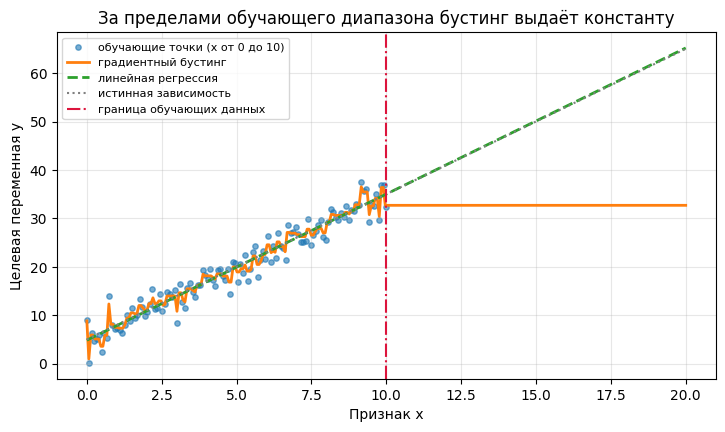

In [18]:
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(3)
x_line = np.linspace(0, 10, 120).reshape(-1, 1)
y_line = 3 * x_line.ravel() + 5 + rng.normal(0, 2, 120)

gb_line = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=2,
                                    random_state=42).fit(x_line, y_line)
lin_line = LinearRegression().fit(x_line, y_line)

x_wide = np.linspace(0, 20, 300).reshape(-1, 1)
print('при x = 20: истинное значение', 3 * 20 + 5,
      '| бустинг', round(float(gb_line.predict([[20.0]])[0]), 1),
      '| линейная регрессия', round(float(lin_line.predict([[20.0]])[0]), 1))
print('максимум, который бустинг вообще способен выдать:',
      round(float(gb_line.predict(x_wide).max()), 1))

plt.figure(figsize=(8.5, 4.5))
plt.scatter(x_line, y_line, s=15, alpha=0.6, label='обучающие точки (x от 0 до 10)')
plt.plot(x_wide, gb_line.predict(x_wide), color='tab:orange', lw=2,
         label='градиентный бустинг')
plt.plot(x_wide, lin_line.predict(x_wide), color='tab:green', ls='--', lw=2,
         label='линейная регрессия')
plt.plot(x_wide, 3 * x_wide.ravel() + 5, color='gray', ls=':', label='истинная зависимость')
plt.axvline(10, color='crimson', ls='-.', label='граница обучающих данных')
plt.xlabel('Признак x')
plt.ylabel('Целевая переменная y')
plt.title('За пределами обучающего диапазона бустинг выдаёт константу')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

**Что видно.** Внутри диапазона $[0, 10]$ оранжевая линия бустинга идёт ступеньками почти по истинной зависимости. Правее красной черты она становится строго горизонтальной: при $x = 20$ бустинг предсказывает **32.7** вместо правильных **65**, а линейная регрессия — **65.2**.

Больше **36.5** эта модель не выдаст никогда, сколько ни увеличивай $x$: максимум суммы средних по листьям ограничен тем, что было в обучающих данных.

Отсюда практическое правило: если прогноз нужен для значений за пределами обучающего диапазона (растущие цены, новые масштабы нагрузки), одного бустинга мало — нужна либо модель с трендом, либо регулярное переобучение на свежих данных.

## 17. Эксплуатация и мониторинг после внедрения

Обученная модель — это файл, который кто-то будет запускать каждый день. У него есть размер, скорость и срок годности.

- **Размер и скорость** растут линейно с числом деревьев. Лишние деревья стоят и памяти, и миллисекунд на каждом прогнозе.
- **Данные меняются** (drift, «дрейф»): распределение признаков в эксплуатации перестаёт совпадать с обучающим. Бустинг это переживает плохо (п. 16), поэтому за распределениями следят.
- **Вероятности не гарантированно откалиброваны** (п. 11) — если по ним принимают денежные решения, калибровку перепроверяют на свежих данных.
- **Модель фиксируют целиком**: версия данных, код обучения, `random_state`, версии библиотек. Иначе воспроизвести результат через полгода не получится.

Посмотрим на цену деревьев в цифрах.

 деревьев  размер модели, КБ  прогноз 10 800 объектов, мс  validation MAE
       50               70.1                          5.4            42.3
      150              194.3                         11.9            31.2
      300              373.7                         25.2            30.3


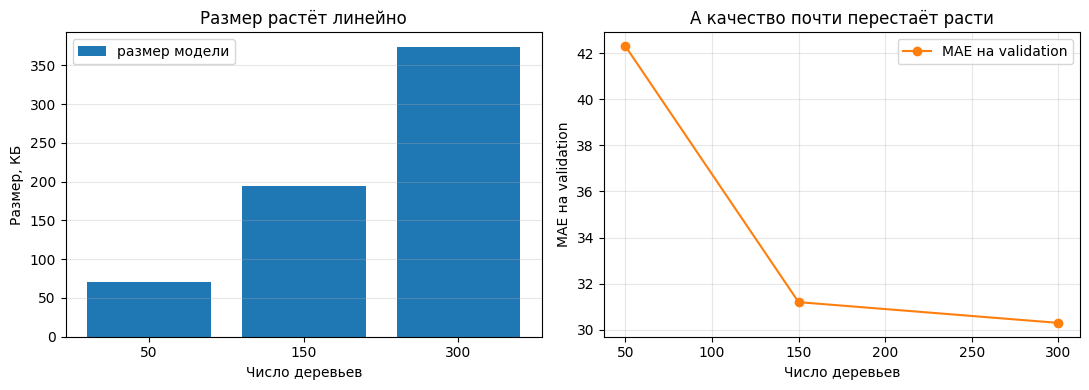

In [19]:
big_batch = np.tile(X_val, (40, 1))   # 10 800 объектов — как один пакет запросов
ops_rows = []
for n_est in [50, 150, 300]:
    model_ops = GradientBoostingRegressor(n_estimators=n_est, learning_rate=0.08,
                                          max_depth=3, random_state=42).fit(X_tr, y_tr)
    size_kb = len(pickle.dumps(model_ops)) / 1024
    t0 = time.perf_counter()
    for _ in range(3):
        model_ops.predict(big_batch)
    predict_ms = (time.perf_counter() - t0) / 3 * 1000
    ops_rows.append({'деревьев': n_est,
                     'размер модели, КБ': round(size_kb, 1),
                     'прогноз 10 800 объектов, мс': round(predict_ms, 1),
                     'validation MAE': round(mean_absolute_error(
                         y_val, model_ops.predict(X_val)), 1)})
ops_df = pd.DataFrame(ops_rows)
print(ops_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(ops_df['деревьев'].astype(str), ops_df['размер модели, КБ'],
            color='tab:blue', label='размер модели')
axes[0].set_xlabel('Число деревьев')
axes[0].set_ylabel('Размер, КБ')
axes[0].set_title('Размер растёт линейно')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend()

axes[1].plot(ops_df['деревьев'], ops_df['validation MAE'], marker='o',
             color='tab:orange', label='MAE на validation')
axes[1].set_xlabel('Число деревьев')
axes[1].set_ylabel('MAE на validation')
axes[1].set_title('А качество почти перестаёт расти')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** Размер модели растёт ровно пропорционально числу деревьев: **70 КБ** при 50 деревьях, **194 КБ** при 150, **374 КБ** при 300. Время прогноза ведёт себя так же: пакет из 10 800 объектов обрабатывается примерно за 5 мс при 50 деревьях и за 25–35 мс при 300 (точные миллисекунды зависят от компьютера, важна пропорция).

А качество ведёт себя иначе: **42.3 → 31.2 → 30.3**. Переход от 50 к 150 деревьям дал 11 единиц MAE, а следующее удвоение — меньше одной, зато удвоило размер и время.

Это и есть инженерное решение, которое принимают перед внедрением: если модель отвечает на тысячи запросов в секунду, 150 деревьев вместо 300 — почти бесплатный выигрыш.

## 18. Анализ ошибок бустинга

Средняя метрика прячет детали. Полезнее посмотреть на **распределение** ошибок и найти группы объектов, где модель систематически промахивается: обычно именно там появляется идея нового признака или ограничения на применение модели.

Порядок действий:

1. посчитать ошибку каждого объекта validation;
2. посмотреть на распределение: где типичная ошибка, где хвост;
3. разбить объекты на группы (по значению признака, по величине цели, по категории) и сравнить среднюю ошибку;
4. сформулировать гипотезу и проверить её **отдельным экспериментом на validation**, а не «на глаз».

медианная ошибка 27.1 | 90-й процентиль 59.6 | максимум 134.4

средняя |ошибка| по квартилям целевой переменной:
группа
Q1 (низкие y)     39.3
Q2                23.8
Q3                26.3
Q4 (высокие y)    34.2
корреляция |ошибки| и |y|: 0.38


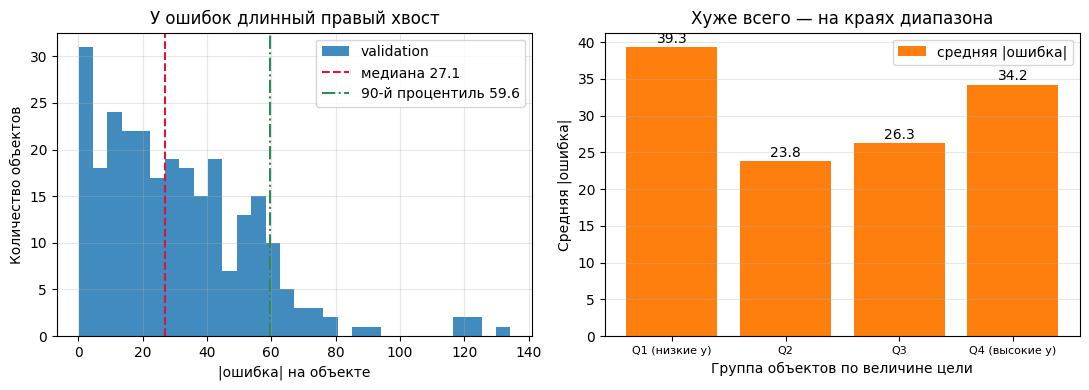

In [20]:
errors = np.abs(y_val - gb.predict(X_val))
print('медианная ошибка', round(float(np.median(errors)), 1),
      '| 90-й процентиль', round(float(np.percentile(errors, 90)), 1),
      '| максимум', round(float(errors.max()), 1))

quartile = pd.qcut(y_val, 4, labels=['Q1 (низкие y)', 'Q2', 'Q3', 'Q4 (высокие y)'])
by_quartile = pd.DataFrame({'группа': quartile, 'ошибка': errors}).groupby(
    'группа', observed=True)['ошибка'].mean()
print()
print('средняя |ошибка| по квартилям целевой переменной:')
print(by_quartile.round(1).to_string())
print('корреляция |ошибки| и |y|:', round(float(np.corrcoef(errors, np.abs(y_val))[0, 1]), 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(errors, bins=30, color='tab:blue', alpha=0.85, label='validation')
axes[0].axvline(np.median(errors), color='crimson', ls='--',
                label=f'медиана {np.median(errors):.1f}')
axes[0].axvline(np.percentile(errors, 90), color='seagreen', ls='-.',
                label=f'90-й процентиль {np.percentile(errors, 90):.1f}')
axes[0].set_xlabel('|ошибка| на объекте')
axes[0].set_ylabel('Количество объектов')
axes[0].set_title('У ошибок длинный правый хвост')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(by_quartile.index.astype(str), by_quartile.values, color='tab:orange',
            label='средняя |ошибка|')
for i, v in enumerate(by_quartile.values):
    axes[1].text(i, v + 0.6, f'{v:.1f}', ha='center', fontsize=10)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].set_xlabel('Группа объектов по величине цели')
axes[1].set_ylabel('Средняя |ошибка|')
axes[1].set_title('Хуже всего — на краях диапазона')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** Половина объектов предсказана с ошибкой меньше **27.1**, но у 10% ошибка больше **59.6**, а рекорд — **134.4**. Хвост длинный, и средняя метрика о нём молчит.

Разбиение по величине цели показывает систему: в средних группах Q2 и Q3 ошибка **23.8** и **26.3**, а на краях — **39.3** (самые низкие значения) и **34.2** (самые высокие). Модель хуже всего работает именно там, где ответы экстремальные, — это прямое следствие того, что деревья возвращают среднее по листу и «стесняются» крайних значений (п. 16).

Что с этим делать дальше: проверить, нет ли у крайних объектов общего признака; попробовать другую функцию потерь; при необходимости честно ограничить область применения модели («для объектов вне обычного диапазона прогноз ненадёжен»).

## 19. Importance: impurity vs permutation

**Feature importance** («важность признака») — попытка ответить на вопрос «на что модель реально опирается». В бустинге есть два основных способа.

**Impurity importance** (`feature_importances_`) — сумма улучшений критерия разбиения по всем узлам, где признак использовался. Считается бесплатно вместе с обучением, но у неё есть известная слабость: она смотрит только на train и склонна завышать важность признаков с большим числом разных значений — им проще случайно оказаться удачным порогом.

**Permutation importance** — честная проверка: берём validation, случайно перемешиваем значения одного признака (связь с целью ломается, распределение сохраняется) и смотрим, насколько просела метрика. Просела сильно — признак важен; не просела — модель без него обойдётся.

Проверим на эксперименте: добавим к десяти настоящим признакам одиннадцатый — чистый случайный шум, никак не связанный с целью. Настоящая важность у него ровно нулевая.

  признак  impurity  permutation
признак 0     0.000       -0.046
признак 5     0.001       -0.004
признак 7     0.001        0.020
признак 3     0.001       -0.164
СЛУЧАЙНЫЙ     0.003        0.023
признак 4     0.008        1.429
признак 6     0.052       15.999
признак 8     0.142       25.328
признак 9     0.159       35.228
признак 2     0.267       46.685
признак 1     0.367       52.130

случайный признак: impurity = 0.003 (место 7 из 11) | permutation = 0.02


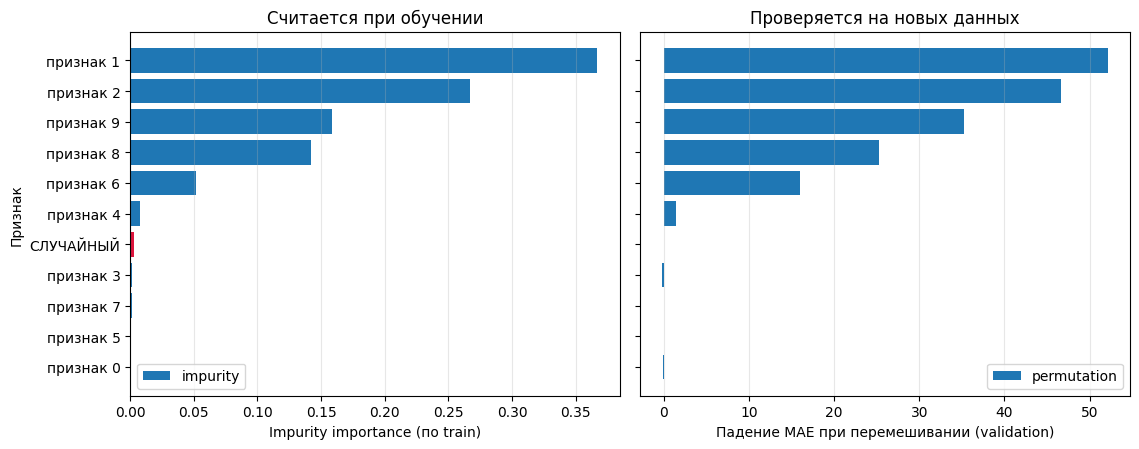

In [21]:
from sklearn.inspection import permutation_importance

rng = np.random.default_rng(21)
X_tr_id = np.hstack([X_tr, rng.normal(size=(len(X_tr), 1)) * 100])
X_val_id = np.hstack([X_val, rng.normal(size=(len(X_val), 1)) * 100])

gb_id = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3,
                                  random_state=42).fit(X_tr_id, y_tr)
perm = permutation_importance(gb_id, X_val_id, y_val, n_repeats=10, random_state=42,
                              scoring='neg_mean_absolute_error')

names = [f'признак {i}' for i in range(X_tr.shape[1])] + ['СЛУЧАЙНЫЙ']
imp_df = pd.DataFrame({'признак': names,
                       'impurity': gb_id.feature_importances_,
                       'permutation': perm.importances_mean}).sort_values('impurity')
print(imp_df.round(3).to_string(index=False))
rank = int((gb_id.feature_importances_ > gb_id.feature_importances_[-1]).sum()) + 1
print()
print('случайный признак: impurity =', round(float(gb_id.feature_importances_[-1]), 3),
      f'(место {rank} из {len(names)})',
      '| permutation =', round(float(perm.importances_mean[-1]), 2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
colors = ['crimson' if n == 'СЛУЧАЙНЫЙ' else 'tab:blue' for n in imp_df['признак']]
axes[0].barh(imp_df['признак'], imp_df['impurity'], color=colors, label='impurity')
axes[0].set_xlabel('Impurity importance (по train)')
axes[0].set_ylabel('Признак')
axes[0].set_title('Считается при обучении')
axes[0].grid(alpha=0.3, axis='x')
axes[0].legend()

axes[1].barh(imp_df['признак'], imp_df['permutation'], color=colors, label='permutation')
axes[1].set_xlabel('Падение MAE при перемешивании (validation)')
axes[1].set_title('Проверяется на новых данных')
axes[1].grid(alpha=0.3, axis='x')
axes[1].legend()
plt.tight_layout()
plt.show()

**Что видно.** Оба способа согласны в главном: важнее всего признаки 1, 2, 9, 8 и 6 — ровно те шесть информативных, которые заложены в данные (шестой, признак 4, заметно слабее).

А теперь про случайный признак. Impurity дала ему **0.003** — вроде бы мало, но этого хватило, чтобы обойти четыре настоящих признака (0, 3, 5, 7) и занять **7-е место из 11**. Permutation честно показала около **0.02** единицы MAE, то есть ноль в пределах шума: выкинуть этот признак — ничего не изменится.

Причина в том, что impurity считается на train: деревьям иногда «везёт» разбить обучающие данные по случайному признаку, и это улучшение засчитывается как польза. На validation везение не повторяется.

И последнее: важность признака — это **не** причинно-следственная связь. Она говорит только «модель на это опирается», а не «это влияет на результат в реальном мире».

## 20. Чек-лист настройки

1. Зафиксировать разбиение (train / validation / test), метрику и baseline. Если объекты связаны в группы или упорядочены во времени — разбивать по группам или по времени (п. 9).
2. Начать с неглубоких деревьев: `max_depth = 3` (п. 5).
3. Поставить умеренный `learning_rate` (0.05–0.1) и заведомо большое число деревьев (п. 4).
4. Построить кривую validation по числу деревьев, найти минимум; включить early stopping, чтобы не платить за лишние итерации (пп. 7–8).
5. Подобрать глубину и минимальный размер листа (`min_samples_leaf`); при большой выборке попробовать `subsample`.
6. Если в цели возможны выбросы — сравнить `squared_error`, `absolute_error` и `huber` (п. 6).
7. Посмотреть на распределение ошибок и на группы с худшим качеством; проверить импортансы через permutation (пп. 18–19).
8. Сравнить с random forest на том же протоколе; учесть время обучения и прогноза (пп. 12–13).
9. На выборках от нескольких тысяч объектов сразу брать `HistGradientBoosting*` (п. 15).
10. Один раз, в самом конце, оценить выбранный вариант на test.

> **Главная мысль.** Бустинг собирает сильную модель из последовательности маленьких исправлений: каждое дерево учится на остатках предыдущих. Поэтому его сила и его слабость — одно и то же свойство: он будет исправлять ошибки до последнего, включая ошибки, которых в реальности нет. Осторожный шаг, неглубокие деревья и честная validation-проверка важнее максимальной сложности.